<a href="https://colab.research.google.com/github/ELOUARDIMustapha/fake-news-app/blob/main/mon_projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ELOUARDIMustapha/fake-news-app/blob/main/mon_projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📰 Détection de Fake News : PFE Master

Ce notebook classe un article de presse en **FAKE** (fausse information) ou **REAL** (information réelle) à partir de son texte.

| Étape | Contenu |
|---|---|
| **0. Configuration** | Installation, imports, paramètres |
| **1. Chargement des données** | Dataset ISOT (`Fake.csv`, `True.csv`) depuis Google Drive |
| **2. Analyse exploratoire** | Répartition des classes, longueur des textes |
| **3. Prétraitement** | Nettoyage, stopwords, lemmatisation |
| **4. Visualisation du vocabulaire** | Mots fréquents, nuage de mots |
| **5. Séparation train / test** | Un seul découpage, commun aux deux modèles |
| **6. Modèle 1 : TF-IDF + LinearSVC** | Modèle classique de Machine Learning |
| **7. Modèle 2 : LSTM** | Modèle de Deep Learning |
| **8. Comparaison des modèles** | Tableau récapitulatif |
| **9. Test sur un nouveau texte** | Fonction de prédiction |
| **10. Sauvegarde** | Modèles enregistrés dans Google Drive |
| **11. Interface Streamlit** | Application web accessible via ngrok |


---
# 0. Configuration

In [1]:
import os
import re
import json
import pickle
import string
import zipfile
import subprocess
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sns.set_theme(style="whitegrid")
print("TensorFlow", tf.__version__, "| GPU :", tf.config.list_physical_devices("GPU") or "aucun")

TensorFlow 2.21.0 | GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Tous les paramètres du projet sont regroupés ici : pour faire une expérience, il suffit de modifier cette cellule.

In [2]:
# --- Chemins -------------------------------------------------------------
DRIVE_DIR    = "/content/drive/MyDrive/mon_projet"     # dossier du projet dans Google Drive
ZIP_PATH     = f"{DRIVE_DIR}/dataset_fake_news.zip"    # archive contenant Fake.csv et True.csv
DATA_DIR     = "/content/dataset"                      # dossier d'extraction
MODELS_DIR   = f"{DRIVE_DIR}/models"                   # où sauvegarder les modèles

# --- Données -------------------------------------------------------------
LABELS = {0: "FAKE", 1: "REAL"}     # Fake.csv -> 0, True.csv -> 1
MIN_TEXT_LENGTH = 10                # on retire les textes plus courts (en caractères)
REMOVE_SOURCE_PREFIX = True         # retire "WASHINGTON (Reuters) - " (voir section 3)

# --- Entraînement --------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE    = 0.2

# --- LSTM ----------------------------------------------------------------
MAX_WORDS     = 20000   # taille du vocabulaire
MAXLEN        = 300     # nombre de mots gardés par article
EMBEDDING_DIM = 100
LSTM_UNITS    = 128
EPOCHS        = 5
BATCH_SIZE    = 64

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

---
# 1. Chargement des données

In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:  # exécution en dehors de Colab
    IN_COLAB = False

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)
print("Fichiers extraits :", os.listdir(DATA_DIR))

Mounted at /content/drive
Fichiers extraits : ['Fake.csv', 'True.csv']


In [4]:
fake = pd.read_csv(f"{DATA_DIR}/Fake.csv")
true = pd.read_csv(f"{DATA_DIR}/True.csv")

fake["label"] = 0   # FAKE
true["label"] = 1   # REAL

print("Fake.csv :", fake.shape, "| True.csv :", true.shape)
fake.head()

Fake.csv : (23481, 5) | True.csv : (21417, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [5]:
# On ne garde que le texte de l'article et son label
df = pd.concat([fake, true], ignore_index=True)[["text", "label"]]

n_initial = len(df)
df = df.dropna(subset=["text"]).drop_duplicates(subset=["text"])
df = df[df["text"].str.strip().str.len() > MIN_TEXT_LENGTH].reset_index(drop=True)

print(f"Articles au départ : {n_initial}")
print(f"Après suppression des doublons et textes vides : {len(df)}")

Articles au départ : 44898
Après suppression des doublons et textes vides : 38632


---
# 2. Analyse exploratoire

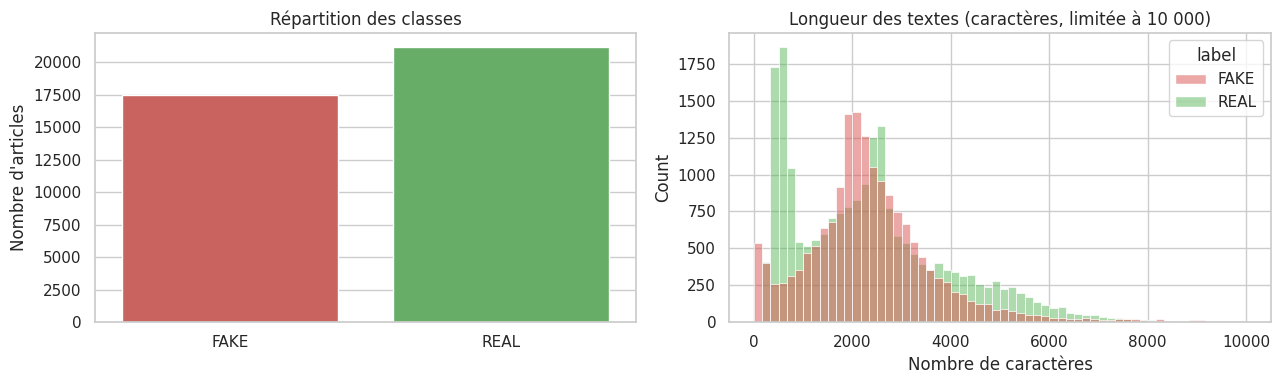

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
FAKE,17441.0,2552.0,2201.0,12.0,1651.0,2235.0,3006.0,51794.0
REAL,21191.0,2379.0,1684.0,152.0,906.0,2216.0,3226.0,29781.0


In [6]:
df["text_length"] = df["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

names = df["label"].map(LABELS)
sns.countplot(x=names, hue=names, order=["FAKE", "REAL"], ax=axes[0],
              palette={"FAKE": "#d9534f", "REAL": "#5cb85c"}, legend=False)
axes[0].set_title("Répartition des classes")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre d'articles")

sns.histplot(data=df, x="text_length", hue=names, bins=60, binrange=(0, 10000),
             palette={"FAKE": "#d9534f", "REAL": "#5cb85c"}, ax=axes[1])
axes[1].set_title("Longueur des textes (caractères, limitée à 10 000)")
axes[1].set_xlabel("Nombre de caractères")

plt.tight_layout()
plt.show()

df.groupby(df["label"].map(LABELS))["text_length"].describe().round(0)

In [7]:
for label, name in LABELS.items():
    print(f"===== Exemple {name} =====")
    print(df[df["label"] == label]["text"].iloc[0][:400], "...\n")

===== Exemple FAKE =====
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishone ...

===== Exemple REAL =====
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard ...



**⚠️ Biais connu du dataset :** la quasi-totalité des articles REAL commencent par une mention de source comme `WASHINGTON (Reuters) -`, ce qui n'est presque jamais le cas des articles FAKE. Un modèle peut alors apprendre à reconnaître *la source* au lieu du *contenu*. Vérifions-le :

In [8]:
has_reuters = df["text"].str[:120].str.contains(r"\(Reuters\)", regex=True)
print(pd.crosstab(df["label"].map(LABELS), has_reuters.rename("contient '(Reuters)' au début"),
                  normalize="index").round(3))

contient '(Reuters)' au début  False  True 
label                                      
FAKE                           1.000  0.000
REAL                           0.013  0.987


---
# 3. Prétraitement du texte

Les étapes de nettoyage sont écrites dans un fichier `preprocessing.py`. Ainsi, **exactement le même traitement** est appliqué à l'entraînement, aux prédictions du notebook et dans l'application Streamlit.

1. Suppression du préfixe de source (`VILLE (Reuters) -`) si `REMOVE_SOURCE_PREFIX = True`
2. Mise en minuscules
3. Suppression des liens, des chiffres et de la ponctuation
4. Suppression des *stopwords* (mots très courants : *the, is, and*…)
5. Lemmatisation (*americans → american*, *enemies → enemy*)

In [9]:
%%writefile preprocessing.py
import re
import string
from functools import lru_cache

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for resource in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(resource, quiet=True)

STOP_WORDS = set(stopwords.words("english"))
_lemmatizer = WordNetLemmatizer()

# Ex. : "WASHINGTON (Reuters) - ", "LONDON/PARIS (Reuters) - ", "(Reuters) - "
SOURCE_PREFIX = re.compile(r"^[^()]{0,80}\(reuters\)\s*-?\s*", flags=re.IGNORECASE)
URLS = re.compile(r"https?://\S+|www\.\S+")
DIGITS = re.compile(r"\d+")
PUNCTUATION = str.maketrans("", "", string.punctuation + "“”‘’—–")


@lru_cache(maxsize=None)
def lemmatize(word):
    return _lemmatizer.lemmatize(word)


def preprocess(text, remove_source_prefix=True):
    """Nettoie un article et renvoie une chaîne de mots lemmatisés."""
    text = str(text)
    if remove_source_prefix:
        text = SOURCE_PREFIX.sub("", text)
    text = text.lower()
    text = URLS.sub(" ", text)
    text = DIGITS.sub(" ", text)
    text = text.translate(PUNCTUATION)
    words = [lemmatize(w) for w in text.split() if w not in STOP_WORDS]
    return " ".join(words)

Writing preprocessing.py


In [10]:
from preprocessing import preprocess

df["clean_text"] = df["text"].apply(preprocess, remove_source_prefix=REMOVE_SOURCE_PREFIX)

# Certains articles peuvent devenir vides après nettoyage
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Avant :", df["text"].iloc[0][:300])
print("\nAprès :", df["clean_text"].iloc[0][:300])
print("\nNombre d'articles final :", len(df))

Avant : Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger a

Après : donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend supporter enemy hater even dishonest fake news medium happy healthy new year president angry pant tweeted

Nombre d'articles final : 38578


---
# 4. Visualisation du vocabulaire

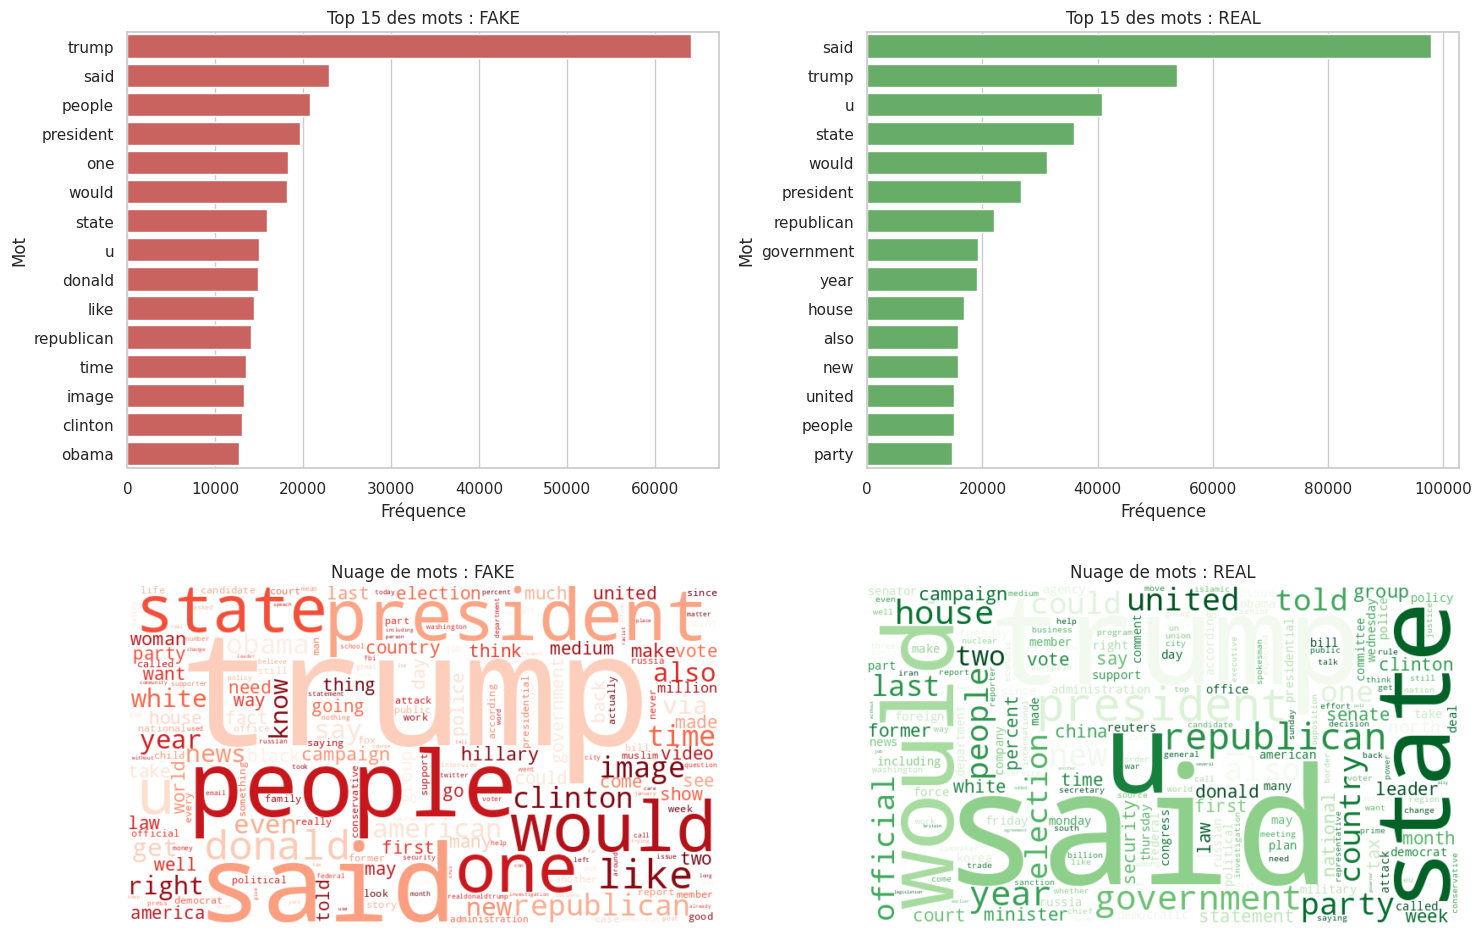

In [11]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col, (label, name) in enumerate(LABELS.items()):
    words = Counter(" ".join(df.loc[df["label"] == label, "clean_text"]).split())
    top = pd.DataFrame(words.most_common(15), columns=["Mot", "Fréquence"])

    sns.barplot(data=top, x="Fréquence", y="Mot", ax=axes[0, col],
                color="#d9534f" if name == "FAKE" else "#5cb85c")
    axes[0, col].set_title(f"Top 15 des mots : {name}")

    cloud = WordCloud(width=700, height=400, background_color="white",
                      colormap="Reds" if name == "FAKE" else "Greens").generate_from_frequencies(words)
    axes[1, col].imshow(cloud, interpolation="bilinear")
    axes[1, col].axis("off")
    axes[1, col].set_title(f"Nuage de mots : {name}")

plt.tight_layout()
plt.show()

---
# 5. Séparation train / test

Un **seul** découpage est utilisé pour les deux modèles afin que leur comparaison soit équitable. L'option `stratify` conserve la même proportion FAKE / REAL dans les deux ensembles.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["label"],
)
print(f"Entraînement : {len(X_train)} articles | Test : {len(X_test)} articles")

Entraînement : 30862 articles | Test : 7716 articles


In [13]:
results = {}  # scores de chaque modèle, pour la comparaison finale


def evaluate(name, y_true, y_pred):
    """Affiche le rapport de classification et la matrice de confusion."""
    results[name] = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
    }
    print(f"===== {name} =====")
    print(classification_report(y_true, y_pred, target_names=list(LABELS.values()), digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=list(LABELS.values()), yticklabels=list(LABELS.values()))
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title(f"Matrice de confusion : {name}")
    plt.show()

---
# 6. Modèle 1 : TF-IDF + LinearSVC

- **TF-IDF** transforme chaque texte en vecteur : un mot pèse lourd s'il est fréquent dans l'article mais rare dans le reste du corpus.
- **LinearSVC** (machine à vecteurs de support linéaire) sépare les deux classes dans cet espace.

===== TF-IDF + LinearSVC =====
              precision    recall  f1-score   support

        FAKE     0.9948    0.9833    0.9890      3478
        REAL     0.9864    0.9958    0.9911      4238

    accuracy                         0.9902      7716
   macro avg     0.9906    0.9895    0.9900      7716
weighted avg     0.9902    0.9902    0.9901      7716



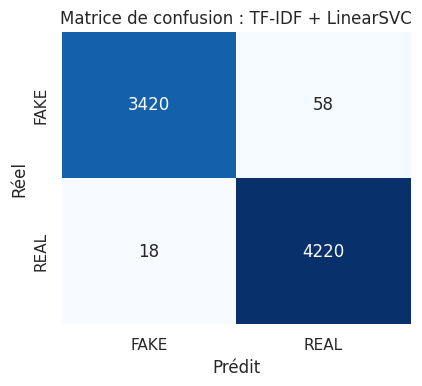

In [14]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)),
    ("clf", LinearSVC(random_state=RANDOM_STATE)),
])
svm_model.fit(X_train, y_train)

evaluate("TF-IDF + LinearSVC", y_test, svm_model.predict(X_test))

**Quels mots influencent le plus la décision ?** Les coefficients du modèle indiquent les mots qui poussent vers FAKE (valeurs négatives) ou vers REAL (valeurs positives).

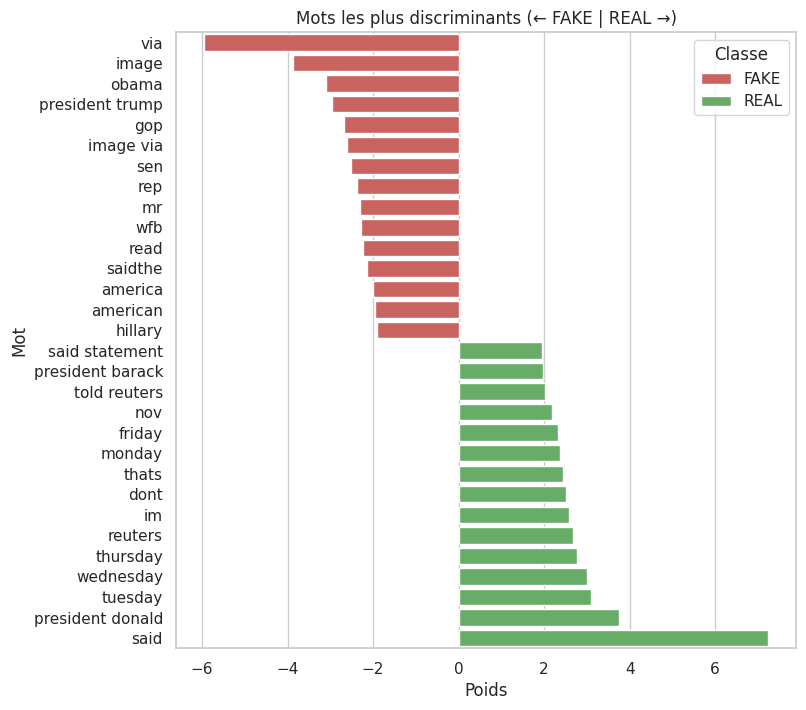

In [15]:
vocab = svm_model.named_steps["tfidf"].get_feature_names_out()
coefs = svm_model.named_steps["clf"].coef_[0]
order = np.argsort(coefs)
top_words = pd.DataFrame({
    "Mot": np.r_[vocab[order[:15]], vocab[order[-15:]]],
    "Poids": np.r_[coefs[order[:15]], coefs[order[-15:]]],
})

plt.figure(figsize=(8, 8))
top_words["Classe"] = np.where(top_words["Poids"] < 0, "FAKE", "REAL")
sns.barplot(data=top_words, x="Poids", y="Mot", hue="Classe",
            palette={"FAKE": "#d9534f", "REAL": "#5cb85c"}, dodge=False)
plt.title("Mots les plus discriminants (← FAKE | REAL →)")
plt.show()

---
# 7. Modèle 2 : LSTM

1. Le **Tokenizer** associe un numéro à chacun des `MAX_WORDS` mots les plus fréquents.
2. Chaque article devient une séquence de `MAXLEN` numéros (complétée par des zéros si nécessaire).
3. Le réseau : **Embedding** (vecteur pour chaque mot) → **LSTM** (lit la séquence dans l'ordre) → **GlobalMaxPooling** → **Dense** → sortie **sigmoïde** (probabilité que l'article soit REAL).

10 % des données d'entraînement servent de **validation** : l'ensemble de test reste inutilisé jusqu'à l'évaluation finale.

In [16]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)  # appris uniquement sur l'entraînement


def to_sequences(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts), maxlen=MAXLEN,
                         padding="post", truncating="post")


X_train_seq = to_sequences(X_train)
X_test_seq = to_sequences(X_test)
print("Forme des données :", X_train_seq.shape)

Forme des données : (30862, 300)


In [17]:
lstm_model = models.Sequential([
    layers.Input(shape=(MAXLEN,)),
    layers.Embedding(MAX_WORDS, EMBEDDING_DIM),
    layers.Dropout(0.3),
    layers.LSTM(LSTM_UNITS, return_sequences=True),
    layers.GlobalMaxPooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                   loss="binary_crossentropy", metrics=["accuracy"])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 300, 128)       │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,125,569 (8.11 MB)

 Trainable params: 2,125,569 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train.values,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop],
)

Epoch 1/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9003 - loss: 0.2562 - val_accuracy: 0.9815 - val_loss: 0.0589
Epoch 2/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9805 - loss: 0.0617 - val_accuracy: 0.9825 - val_loss: 0.0537
Epoch 3/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9929 - loss: 0.0265 - val_accuracy: 0.9887 - val_loss: 0.0403
Epoch 4/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9976 - loss: 0.0096 - val_accuracy: 0.9857 - val_loss: 0.0541
Epoch 5/5
434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9987 - loss: 0.0051 - val_accuracy: 0.9893 - val_loss: 0.0416


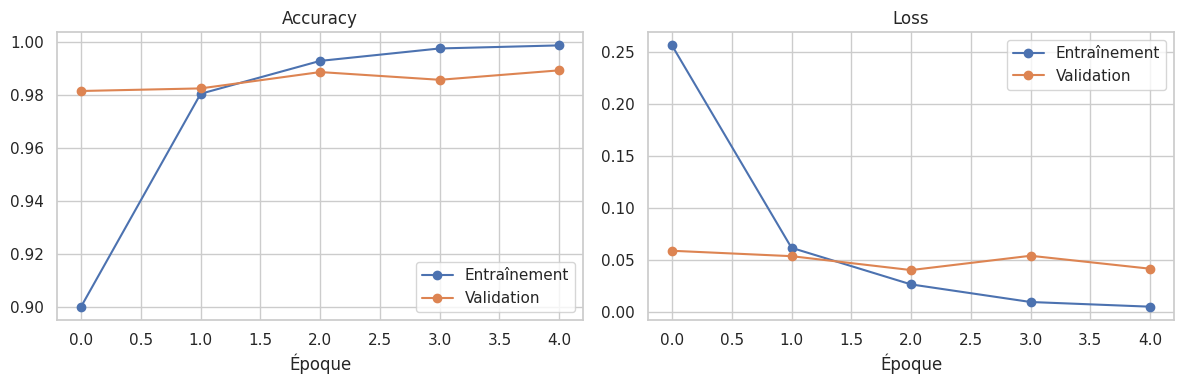

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history.history[metric], marker="o", label="Entraînement")
    ax.plot(history.history[f"val_{metric}"], marker="o", label="Validation")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Époque")
    ax.legend()
plt.tight_layout()
plt.show()

===== LSTM =====
              precision    recall  f1-score   support

        FAKE     0.9889    0.9721    0.9804      3478
        REAL     0.9774    0.9910    0.9842      4238

    accuracy                         0.9825      7716
   macro avg     0.9832    0.9816    0.9823      7716
weighted avg     0.9826    0.9825    0.9825      7716



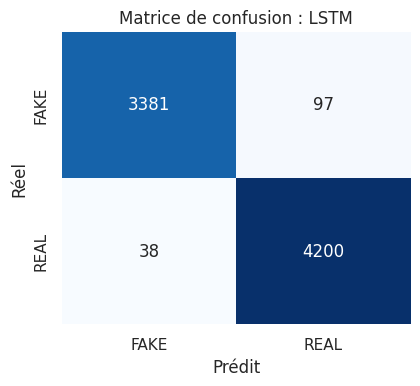

In [20]:
lstm_proba = lstm_model.predict(X_test_seq, verbose=0).ravel()
evaluate("LSTM", y_test, (lstm_proba >= 0.5).astype(int))

---
# 8. Comparaison des modèles

In [21]:
comparison = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
comparison.style.format("{:.2%}").highlight_max(color="#c8e6c9")

,Accuracy,F1 (macro)
TF-IDF + LinearSVC,99.02%,99.00%
LSTM,98.25%,98.23%


---
# 9. Test sur un nouveau texte

In [22]:
def predict_news(text):
    """Renvoie la prédiction des deux modèles pour un texte brut."""
    clean = preprocess(text, remove_source_prefix=REMOVE_SOURCE_PREFIX)
    svm_pred = int(svm_model.predict([clean])[0])
    p_real = float(lstm_model.predict(to_sequences([clean]), verbose=0)[0, 0])
    return {
        "TF-IDF + LinearSVC": LABELS[svm_pred],
        "LSTM": f"{LABELS[int(p_real >= 0.5)]} (probabilité REAL = {p_real:.1%})",
    }


examples = [
    "The Federal Reserve raised interest rates by a quarter point on Wednesday, "
    "citing continued strength in the labor market, officials said in a statement.",
    "BREAKING: Hillary caught on tape admitting the election was rigged!!! "
    "Share this before they delete it, the mainstream media will never show you this.",
]
for text in examples:
    print(text[:90], "...")
    print("  ->", predict_news(text), "\n")

The Federal Reserve raised interest rates by a quarter point on Wednesday, citing continue ...
  -> {'TF-IDF + LinearSVC': 'REAL', 'LSTM': 'REAL (probabilité REAL = 100.0%)'} 

BREAKING: Hillary caught on tape admitting the election was rigged!!! Share this before th ...
  -> {'TF-IDF + LinearSVC': 'FAKE', 'LSTM': 'FAKE (probabilité REAL = 0.2%)'} 



---
# 10. Sauvegarde des modèles

Les modèles sont enregistrés dans Google Drive : ils ne seront pas perdus à la fin de la session Colab.

In [23]:
os.makedirs(MODELS_DIR, exist_ok=True)

lstm_model.save(f"{MODELS_DIR}/lstm_model.keras")
joblib.dump(svm_model, f"{MODELS_DIR}/svm_model.joblib")
with open(f"{MODELS_DIR}/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open(f"{MODELS_DIR}/config.json", "w") as f:
    json.dump({"MAXLEN": MAXLEN, "REMOVE_SOURCE_PREFIX": REMOVE_SOURCE_PREFIX, "LABELS": LABELS}, f)

print("Modèles sauvegardés dans", MODELS_DIR, ":", os.listdir(MODELS_DIR))

Modèles sauvegardés dans /content/drive/MyDrive/mon_projet/models : ['lstm_model.keras', 'svm_model.joblib', 'tokenizer.pkl', 'config.json']
